# ReFRAME library dataset analysis

In [1]:
import os
import warnings
from itertools import combinations

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from benchmarking.constants import (
    INCHIKEY_COLUMN,
    SCORE_COLUMN,
    TOOL_COLORS,
    TOOL_NAMES,
)
from benchmarking.metrics.base_metrics import load_all_feature_tables

# Load in data

In [2]:
ground_truth_library_data = pd.read_parquet(
    "../data/library_spectra/reframe_spikein_lib.pq"
)
ground_truth_ccs_data = pd.read_parquet(
    "../data/library_spectra/reframe_ms2s_with_ccs.parquet"
)

In [3]:
# Building the feature table for reframe_spikein_dataset
merged_feature_tables = load_all_feature_tables(
    ["../data/groundtruth_dataset/MSV000098263"],
    annotation_subfolder="annotated_spectral_entropy",
)

100%|██████████| 1/1 [00:01<00:00,  1.62s/it]


# CCS-based structural isomer discrimination analysis

We identify **structural isomer** pairs from the ReFRAME library — compounds with
different 2D InChIKey (different atom connectivity) but the **same molecular formula**
(resolved via PubChem lookup, cached locally). This ensures we compare true isomers
rather than isobaric compounds that happen to share a similar m/z but have different
elemental compositions.

For each structural isomer pair we compute the relative CCS difference (ΔCCS%) and
categorise it following the discrimination thresholds from Yin *et al.* (2023)
*Nat Commun* (doi:10.1038/s41467-023-37539-0):

| ΔCCS% | Discrimination capability |
|-------|--------------------------|
| ≥ 4 % | Baseline IM separation (RP ≥ 50) |
| 2–4 % | Half-peak-height IM separation (RP ≥ 100) |
| 1–2 % | Requires LC × IM dual separation |
| < 1 % | Depends on LC separation alone |

In [4]:
import json
import time

import pubchempy as pcp
from tqdm.auto import tqdm

MZ_TOL = 0.01  # Da — ensures same-adduct pairing

gt = ground_truth_ccs_data.copy()
gt["inchikey_prefix"] = gt["inchikey_2d"].str[:14]

# ── Deduplicate: collapse repeated measurements of the same compound+adduct ───
n_before = len(gt)
gt["mz_bin"] = gt["precursor_mz"].round(2)
gt = gt.groupby(["inchikey_2d", "mz_bin"], as_index=False).agg(
    precursor_mz=("precursor_mz", "mean"),
    ccs=("ccs", "mean"),
    inchikey_prefix=("inchikey_prefix", "first"),
)
gt = gt.drop(columns=["mz_bin"]).reset_index(drop=True)
print(
    f"Deduplicated: {n_before} → {len(gt)} entries "
    f"(removed {n_before - len(gt)} duplicate measurements)"
)


def _delta_ccs_pct(ccs_a, ccs_b):
    return abs(ccs_a - ccs_b) / ((ccs_a + ccs_b) / 2) * 100


# ── Resolve molecular formulae via PubChem (with local caching) ───────────────
FORMULA_CACHE_PATH = "../data/cache/inchikey_formula_map.json"


def _load_formula_cache():
    try:
        with open(FORMULA_CACHE_PATH) as f:
            return json.load(f)
    except FileNotFoundError:
        return {}


def _save_formula_cache(cache):
    os.makedirs(os.path.dirname(FORMULA_CACHE_PATH), exist_ok=True)
    with open(FORMULA_CACHE_PATH, "w") as f:
        json.dump(cache, f, indent=2, sort_keys=True)


def resolve_formulae(inchikeys, batch_size=50):
    """Resolve InChIKeys → molecular formulae via PubChem (pubchempy), with local JSON caching."""
    cache = _load_formula_cache()
    unique_keys = sorted(set(inchikeys))
    missing = [k for k in unique_keys if k not in cache]

    if missing:
        n_batches = (len(missing) + batch_size - 1) // batch_size
        for i in tqdm(
            range(0, len(missing), batch_size),
            total=n_batches,
            desc="Resolving InChIKeys via PubChem",
            unit="batch",
        ):
            batch = missing[i : i + batch_size]
            try:
                props = pcp.get_properties(
                    "InChIKey,MolecularFormula",
                    ",".join(batch),
                    "inchikey",
                )
                resp_map = {}
                for p in props:
                    prefix = p.get("InChIKey", "")[:14]
                    resp_map[prefix] = p.get("MolecularFormula", "")
                for query_ik in batch:
                    prefix = query_ik[:14]
                    if prefix in resp_map:
                        cache[query_ik] = resp_map[prefix]
            except Exception as e:
                tqdm.write(f"  Batch {i // batch_size + 1} error: {e}")

            if i + batch_size < len(missing):
                time.sleep(0.25)

        _save_formula_cache(cache)
        n_resolved = sum(1 for k in missing if k in cache)
        print(f"Resolved {n_resolved}/{len(missing)}, total cached: {len(cache)}")
    else:
        print(f"All {len(unique_keys)} InChIKeys found in cache.")

    return {k: cache.get(k) for k in unique_keys}


# Resolve formulae for all library entries
formula_map = resolve_formulae(gt["inchikey_2d"].unique().tolist())
gt["molecular_formula"] = gt["inchikey_2d"].map(formula_map)

n_with_formula = gt["molecular_formula"].notna().sum()
print(f"\nEntries with formula: {n_with_formula}/{len(gt)}")
print(f"Unique formulae:      {gt['molecular_formula'].nunique()}")


# ── Structural isomers ─────────────────────────────────────────────────────────
# Same molecular formula + different InChIKey connectivity prefix.
# The m/z filter (±MZ_TOL) ensures we compare the same adduct species.

gt_with_formula = gt.dropna(subset=["molecular_formula"])

struct_rows = []
for formula, grp in gt_with_formula.groupby("molecular_formula"):
    entries = grp.reset_index(drop=True)
    prefixes = entries["inchikey_prefix"].unique()
    if len(prefixes) < 2:
        continue

    for i, j in combinations(range(len(entries)), 2):
        if entries.loc[i, "inchikey_prefix"] != entries.loc[j, "inchikey_prefix"]:
            if (
                abs(entries.loc[i, "precursor_mz"] - entries.loc[j, "precursor_mz"])
                > MZ_TOL
            ):
                continue
            ccs_a = entries.loc[i, "ccs"]
            ccs_b = entries.loc[j, "ccs"]
            struct_rows.append(
                {
                    "inchikey_a": entries.loc[i, "inchikey_2d"],
                    "inchikey_b": entries.loc[j, "inchikey_2d"],
                    "formula": formula,
                    "mz": (
                        entries.loc[i, "precursor_mz"] + entries.loc[j, "precursor_mz"]
                    )
                    / 2,
                    "ccs_a": ccs_a,
                    "ccs_b": ccs_b,
                    "delta_ccs_abs": abs(ccs_a - ccs_b),
                    "delta_ccs_pct": _delta_ccs_pct(ccs_a, ccs_b),
                    "isomer_type": "Structural isomers",
                }
            )

all_pairs = pd.DataFrame(struct_rows)

print(f"\nStructural isomer pairs: {len(all_pairs):>5}")
print()
print(all_pairs["delta_ccs_pct"].describe().round(2))

Deduplicated: 7219 → 6485 entries (removed 734 duplicate measurements)


Resolving InChIKeys via PubChem: 100%|██████████| 1/1 [00:00<00:00,  1.99batch/s]


Resolved 0/16, total cached: 5340

Entries with formula: 6468/6485
Unique formulae:      4708

Structural isomer pairs:   858

count    858.00
mean       3.22
std        3.02
min        0.00
25%        0.96
50%        2.23
75%        4.63
max       16.68
Name: delta_ccs_pct, dtype: float64


In [5]:
CATEGORY_ORDER = ["≥4%", "2–4%", "1–2%", "<1%"]
CATEGORY_COLORS = ["#2E8B57", "#82C99E", "#F4A261", "#E76F51"]
CATEGORY_LABELS = {
    "≥4%": "≥4%\n(baseline IM)",
    "2–4%": "2–4%\n(partial IM)",
    "1–2%": "1–2%\n(LC×IM)",
    "<1%": "<1%\n(LC only)",
}


def assign_ccs_category(pct):
    if pct >= 4.0:
        return "≥4%"
    elif pct >= 2.0:
        return "2–4%"
    elif pct >= 1.0:
        return "1–2%"
    return "<1%"


all_pairs["ccs_category"] = all_pairs["delta_ccs_pct"].apply(assign_ccs_category)

cat_counts = all_pairs.groupby("ccs_category").size().reset_index(name="count")
cat_counts["pct"] = cat_counts["count"] / cat_counts["count"].sum() * 100

# Build series indexed by category for plotting
cat_pct = cat_counts.set_index("ccs_category")["pct"].reindex(CATEGORY_ORDER).fillna(0)
cat_n = (
    cat_counts.set_index("ccs_category")["count"]
    .reindex(CATEGORY_ORDER)
    .fillna(0)
    .astype(int)
)

print("Fraction (%) of structural isomer pairs in each ΔCCS% category:")
display(pd.DataFrame({"pct": cat_pct.round(1), "n": cat_n}))

Fraction (%) of structural isomer pairs in each ΔCCS% category:


,pct,n
ccs_category,,
≥4%,30.1,258
2–4%,23.8,204
1–2%,19.7,169
<1%,26.5,227


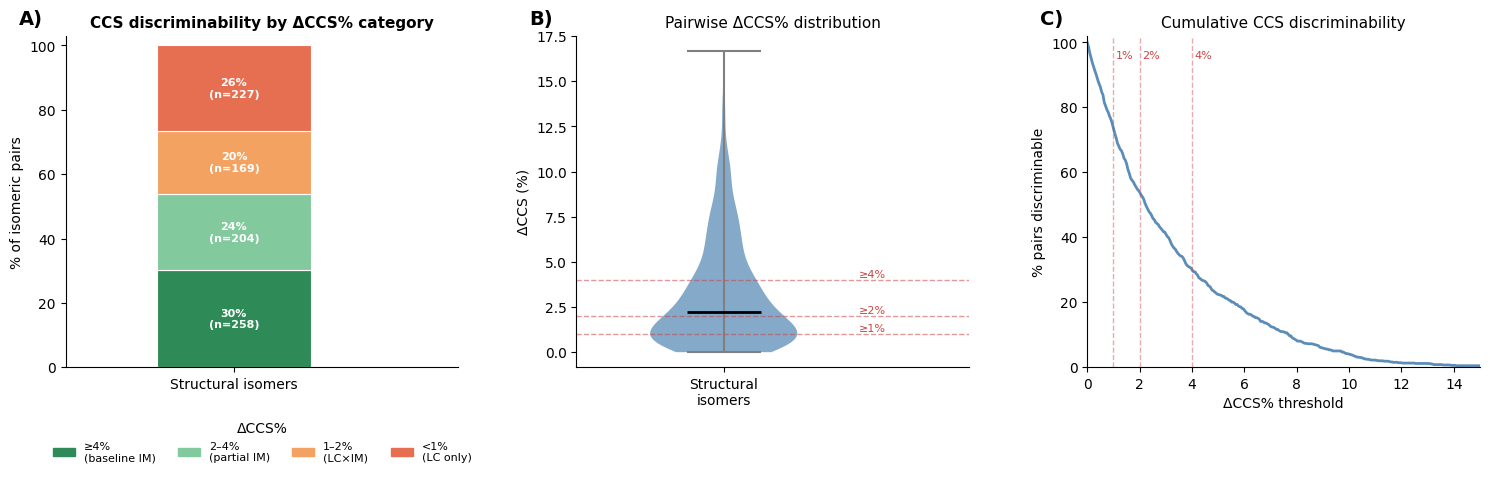

In [6]:
STRUCT_COLOR = "#5B8DB8"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel A: stacked bar of ΔCCS% categories ──────────────────────────────
ax_bar = axes[0]
bottom = 0.0
for cat, color in zip(CATEGORY_ORDER, CATEGORY_COLORS):
    v = cat_pct[cat]
    n = cat_n[cat]
    ax_bar.bar(
        0,
        v,
        bottom=bottom,
        color=color,
        width=0.55,
        edgecolor="white",
        linewidth=0.8,
        label=CATEGORY_LABELS[cat],
    )
    if v > 6:
        ax_bar.text(
            0,
            bottom + v / 2,
            f"{v:.0f}%\n(n={n:,})",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold",
        )
    bottom += v

ax_bar.set_xticks([0])
ax_bar.set_xticklabels(["Structural isomers"], fontsize=10)
ax_bar.set_ylabel("% of isomeric pairs", fontsize=10)
ax_bar.set_title(
    "CCS discriminability by ΔCCS% category", fontsize=11, fontweight="bold"
)
ax_bar.set_ylim(0, 103)
ax_bar.set_xlim(-0.6, 0.8)
ax_bar.spines[["top", "right"]].set_visible(False)
handles = [
    mpatches.Patch(color=c, label=CATEGORY_LABELS[cat])
    for cat, c in zip(CATEGORY_ORDER, CATEGORY_COLORS)
]
ax_bar.legend(
    handles=handles,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    title="ΔCCS%",
    title_fontsize=10,
    frameon=False,
    borderaxespad=0,
    ncol=4,
)

# ── Panel B: violin of ΔCCS% distribution ─────────────────────────────────────
ax = axes[1]
data = all_pairs["delta_ccs_pct"].values
parts = ax.violinplot(
    [data], positions=[0], showmedians=True, showextrema=True, widths=0.6
)
for pc in parts["bodies"]:
    pc.set_facecolor(STRUCT_COLOR)
    pc.set_alpha(0.75)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)
for key in ("cbars", "cmins", "cmaxes"):
    parts[key].set_color("grey")

for thresh, label in [(4.0, "≥4%"), (2.0, "≥2%"), (1.0, "≥1%")]:
    ax.axhline(thresh, color="#CC4444", linestyle="--", alpha=0.55, linewidth=1)
    ax.text(0.55, thresh + 0.05, label, fontsize=8, color="#CC4444", va="bottom")

ax.set_xticks([0])
ax.set_xticklabels(["Structural\nisomers"], fontsize=10)
ax.set_xlim(-0.6, 1.0)
ax.set_ylabel("ΔCCS (%)", fontsize=10)
ax.set_title("Pairwise ΔCCS% distribution", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

# ── Panel C: cumulative discriminability curve ────────────────────────────────
ax2 = axes[2]
thresholds = np.linspace(0, 15, 300)
cumfrac = [(data >= thr).mean() * 100 for thr in thresholds]
ax2.plot(thresholds, cumfrac, color=STRUCT_COLOR, linewidth=2)

for thresh, label in [(1.0, "1%"), (2.0, "2%"), (4.0, "4%")]:
    ax2.axvline(thresh, color="#CC4444", linestyle="--", alpha=0.45, linewidth=1)
    ax2.text(thresh + 0.08, 95, label, fontsize=8, color="#CC4444")

ax2.set_xlabel("ΔCCS% threshold", fontsize=10)
ax2.set_ylabel("% pairs discriminable", fontsize=10)
ax2.set_title("Cumulative CCS discriminability", fontsize=11)
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 102)
ax2.spines[["top", "right"]].set_visible(False)


# ── Panel labels ───────────────────────────────────────────────────────────────
for panel_ax, label in zip(axes, ["A)", "B)", "C)"]):
    panel_ax.text(
        -0.12,
        1.08,
        label,
        transform=panel_ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
    )

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/supplementary_figure_10.png", bbox_inches="tight", dpi=400)
plt.show()

## Tool-level structural isomer discrimination

For each tool we ask: **does the tool's feature detection output allow discrimination
of structural isomer pairs found in the library?**

Both members of a structural isomer pair have distinct InChIKeys. A pair is
*discriminated* when both are true positives AND the CCS values reported by
the tool satisfy |ΔCCS_tool%| ≥ threshold. Matching uses the 14-character
InChIKey connectivity block so tool InChIKeys (which may include stereo) align
correctly with the 2D library keys.

The per-tool *discrimination rate* is the fraction of detectable pairs
where the CCS separation is ≥ `DISC_THRESHOLD` (default 1%).

In [7]:
SCORE_THRESHOLD = 0.7
DISC_THRESHOLD = 1.0  # minimum ΔCCS% to call a pair "discriminated"

# First-block lookup for the library (14-char connectivity hash)
gt_blocks = set(gt["inchikey_2d"].str[:14])


def compute_tool_discrimination(feature_df, isomeric_pairs_df, disc_thr=DISC_THRESHOLD):
    """
    Compute the CCS-based discrimination rate for structural isomers.

    Returns the fraction of same-m/z pairs (different InChIKey) where both
    are TPs and the tool reports |ΔCCS%| ≥ disc_thr.
    """
    df = feature_df.copy()

    df["inchikey_block1"] = df[INCHIKEY_COLUMN].apply(
        lambda x: x.split("-")[0] if pd.notna(x) else None
    )

    df_tp = df[
        (df[SCORE_COLUMN].notna())
        & (df[SCORE_COLUMN] >= SCORE_THRESHOLD)
        & (df["inchikey_block1"].isin(gt_blocks))
    ]

    # Best-score CCS per connectivity block
    tool_ccs_best = (
        df_tp.sort_values(SCORE_COLUMN, ascending=False)
        .groupby("inchikey_block1")["CCS"]
        .first()
        .to_dict()
    )
    detected_blocks = set(tool_ccs_best.keys())

    n_det, n_disc = 0, 0
    for _, row in isomeric_pairs_df.iterrows():
        block_a = row["inchikey_a"][:14]
        block_b = row["inchikey_b"][:14]
        if block_a not in detected_blocks or block_b not in detected_blocks:
            continue
        n_det += 1
        if _delta_ccs_pct(tool_ccs_best[block_a], tool_ccs_best[block_b]) >= disc_thr:
            n_disc += 1

    rate = n_disc / n_det * 100 if n_det > 0 else np.nan
    return {"n_detectable": n_det, "n_discriminated": n_disc, "rate": rate}


# ── Run for each tool ──────────────────────────────────────────────────────────
disc_results = {}

if not merged_feature_tables:
    print(
        "⚠️  merged_feature_tables is empty — tool data could not be loaded.\n"
        "    Ensure the harmonized feature tables exist at:\n"
        "    data/groundtruth_dataset/MSV000098263/harmonized/\n"
        "    and that the annotated_spectral_entropy parquet files are complete."
    )
else:
    for tool, df in merged_feature_tables.items():
        disc_results[TOOL_NAMES[tool]] = compute_tool_discrimination(df, all_pairs)

    rows = []
    for tool_name, vals in disc_results.items():
        rows.append({"Tool": tool_name, **vals})
    display(pd.DataFrame(rows))

,Tool,n_detectable,n_discriminated,rate
0,MetaboScape,487,387,79.466119
1,MS-DIAL,207,164,79.227053
2,MZmine,704,514,73.011364


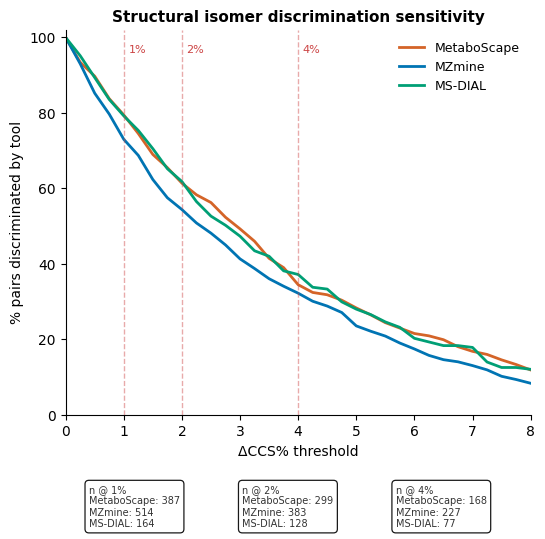

In [8]:
if not merged_feature_tables:
    print("Skipping sensitivity plot — no tool data loaded.")
else:
    thresholds_sweep = np.arange(0, 8.1, 0.25)
    CUT_THRESHOLDS = [(1.0, "1%"), (2.0, "2%"), (4.0, "4%")]

    tool_keys_present = [
        k for k in ["metaboscape", "mzmine", "msdial"] if TOOL_NAMES[k] in disc_results
    ]

    # Pre-compute per-tool n_discriminated at each cut threshold
    cut_counts = {}
    for thresh, _ in CUT_THRESHOLDS:
        per_tool = {}
        for tool_key in tool_keys_present:
            res = compute_tool_discrimination(
                merged_feature_tables[tool_key], all_pairs, disc_thr=thresh
            )
            per_tool[TOOL_NAMES[tool_key]] = res["n_discriminated"]
        cut_counts[thresh] = per_tool

fig, ax_s = plt.subplots(figsize=(6, 5))
box_x_positions = [0.05, 0.38, 0.71]

for tool_key in tool_keys_present:
    tool_name = TOOL_NAMES[tool_key]
    rates_by_thresh = []
    for thr in thresholds_sweep:
        res = compute_tool_discrimination(
            merged_feature_tables[tool_key], all_pairs, disc_thr=thr
        )
        rates_by_thresh.append(res["rate"])
    ax_s.plot(
        thresholds_sweep,
        rates_by_thresh,
        color=TOOL_COLORS[tool_key],
        linewidth=2,
        label=tool_name,
    )

for thresh, label in CUT_THRESHOLDS:
    ax_s.axvline(thresh, color="#CC4444", linestyle="--", alpha=0.45, linewidth=1)
    ax_s.text(thresh + 0.08, 98, label, fontsize=8, color="#CC4444", va="top")

# Annotation boxes below the axis
for bx, (thresh, label) in zip(box_x_positions, CUT_THRESHOLDS):
    per_tool_n = cut_counts[thresh]
    box_lines = [f"n @ {label}"] + [
        f"{TOOL_NAMES[k]}: {per_tool_n[TOOL_NAMES[k]]:,}" for k in tool_keys_present
    ]
    ax_s.text(
        bx,
        -0.18,
        "\n".join(box_lines),
        fontsize=7,
        color="#333333",
        va="top",
        ha="left",
        transform=ax_s.transAxes,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="black",
            alpha=0.9,
            linewidth=0.9,
        ),
    )

ax_s.set_xlabel("ΔCCS% threshold", fontsize=10)
ax_s.set_ylabel("% pairs discriminated by tool", fontsize=10)
ax_s.set_title(
    "Structural isomer discrimination sensitivity", fontsize=11, fontweight="bold"
)
ax_s.set_xlim(0, 8)
ax_s.set_ylim(0, 102)
ax_s.legend(fontsize=9, frameon=False)
ax_s.spines[["top", "right"]].set_visible(False)

plt.savefig(
    "../figures/figure_3d.png",
    bbox_inches="tight",
    dpi=400,
)
plt.show()

## Example structural isomer pairs

Examples of **structural isomers** (same molecular formula, different connectivity)
drawn with RDKit, sorted by lowest m/z (simplest structures).

SMILES are resolved from InChIKeys via PubChem (cached locally alongside the
formula cache).

Resolving SMILES via PubChem: 100%|██████████| 23/23 [00:22<00:00,  1.02batch/s]

Resolved 1116/1116 SMILES

────────────────────────────────────────────────────────────
  Structural isomers — 3 lowest-m/z example pairs
────────────────────────────────────────────────────────────
  ΔCCS=0.64%  formula=C15H16N2O  (CNNZLFXCUQLKOB vs JROSDBYIFZWPBP)
  ΔCCS=10.81%  formula=C15H20N2O2  (FVNFBBAOMBJTST vs VHFZHENYANJUKP)
  ΔCCS=1.56%  formula=C16H23NO2  (DKLKMKYDWHYZTD vs SSEBTPPFLLCUMN)


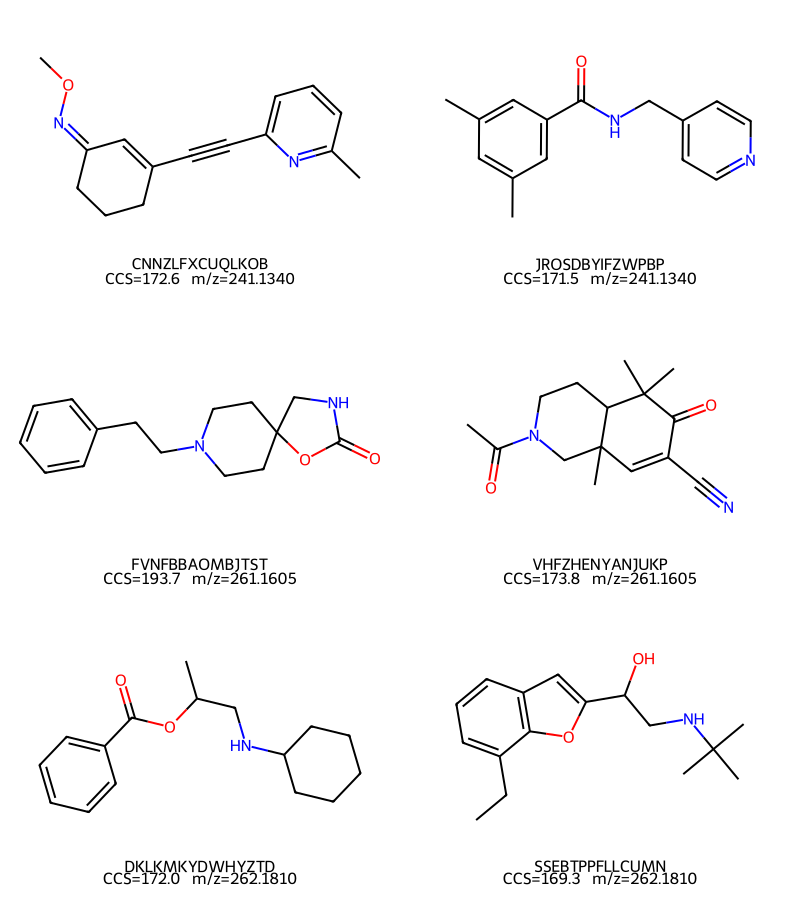

In [9]:
import json
import time

import pubchempy as pcp
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw
from tqdm.auto import tqdm

# ── Resolve InChIKeys → SMILES via PubChem (with local caching) ───────────────
SMILES_CACHE_PATH = "../data/cache/inchikey_smiles_map.json"


def _load_smiles_cache():
    try:
        with open(SMILES_CACHE_PATH) as f:
            return json.load(f)
    except FileNotFoundError:
        return {}


def _save_smiles_cache(cache):
    os.makedirs(os.path.dirname(SMILES_CACHE_PATH), exist_ok=True)
    with open(SMILES_CACHE_PATH, "w") as f:
        json.dump(cache, f, indent=2, sort_keys=True)


def resolve_smiles(inchikeys, batch_size=50):
    """Resolve InChIKeys → IsomericSMILES via PubChem, with local JSON caching."""
    cache = _load_smiles_cache()
    unique_keys = sorted(set(inchikeys))
    missing = [k for k in unique_keys if k not in cache]

    if missing:
        for i in tqdm(
            range(0, len(missing), batch_size),
            total=(len(missing) + batch_size - 1) // batch_size,
            desc="Resolving SMILES via PubChem",
            unit="batch",
        ):
            batch = missing[i : i + batch_size]
            try:
                props = pcp.get_properties(
                    "InChIKey,IsomericSMILES",
                    ",".join(batch),
                    "inchikey",
                )
                resp_map = {}
                for p in props:
                    prefix = (p.get("InChIKey") or p.get("InChiKey", ""))[:14]
                    smi = p.get("IsomericSMILES") or p.get("SMILES", "")
                    resp_map[prefix] = smi
                for query_ik in batch:
                    prefix = query_ik[:14]
                    if prefix in resp_map:
                        cache[query_ik] = resp_map[prefix]
            except Exception as e:
                tqdm.write(f"  Batch {i // batch_size + 1} error: {e}")
            if i + batch_size < len(missing):
                time.sleep(0.25)
        _save_smiles_cache(cache)
        print(f"Resolved {sum(1 for k in missing if k in cache)}/{len(missing)} SMILES")
    else:
        print(f"All {len(unique_keys)} SMILES found in cache.")

    return {k: cache.get(k) for k in unique_keys}


# Collect all unique InChIKeys from the pairs
all_iks = set(all_pairs["inchikey_a"]) | set(all_pairs["inchikey_b"])
smiles_map = resolve_smiles(list(all_iks))

N_EXAMPLES = 3


def _draw_pair_row(pair_row, smiles_map):
    """Return (mols, legends) for a single pair."""
    smi_a = smiles_map.get(pair_row["inchikey_a"])
    smi_b = smiles_map.get(pair_row["inchikey_b"])
    mol_a = Chem.MolFromSmiles(smi_a) if smi_a else None
    mol_b = Chem.MolFromSmiles(smi_b) if smi_b else None
    leg_a = (
        f'{pair_row["inchikey_a"][:14]}\n'
        f'CCS={pair_row["ccs_a"]:.1f}  m/z={pair_row["mz"]:.4f}'
    )
    leg_b = (
        f'{pair_row["inchikey_b"][:14]}\n'
        f'CCS={pair_row["ccs_b"]:.1f}  m/z={pair_row["mz"]:.4f}'
    )
    return [mol_a, mol_b], [leg_a, leg_b]


# Only structural isomers
candidates = all_pairs[
    all_pairs["inchikey_a"].map(lambda k: smiles_map.get(k) is not None)
    & all_pairs["inchikey_b"].map(lambda k: smiles_map.get(k) is not None)
]
sample = candidates.nsmallest(N_EXAMPLES, "mz")

mols, legends = [], []
for _, row in sample.iterrows():
    m, l = _draw_pair_row(row, smiles_map)
    mols.extend(m)
    legends.extend(l)

print(f"\n{'─' * 60}")
print(f"  Structural isomers — {len(sample)} lowest-m/z example pairs")
print(f"{'─' * 60}")
for _, row in sample.iterrows():
    print(
        f"  ΔCCS={row['delta_ccs_pct']:.2f}%  "
        f"formula={row['formula']}  "
        f"({row['inchikey_a'][:14]} vs {row['inchikey_b'][:14]})"
    )

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=legends,
)
display(img)

### Example: CCS % error for a structural isomer pair across tools

Pick one structural isomer pair that all three tools detected as true positives
and compare each tool's **CCS % error** (relative to the library reference CCS)
for both compounds.

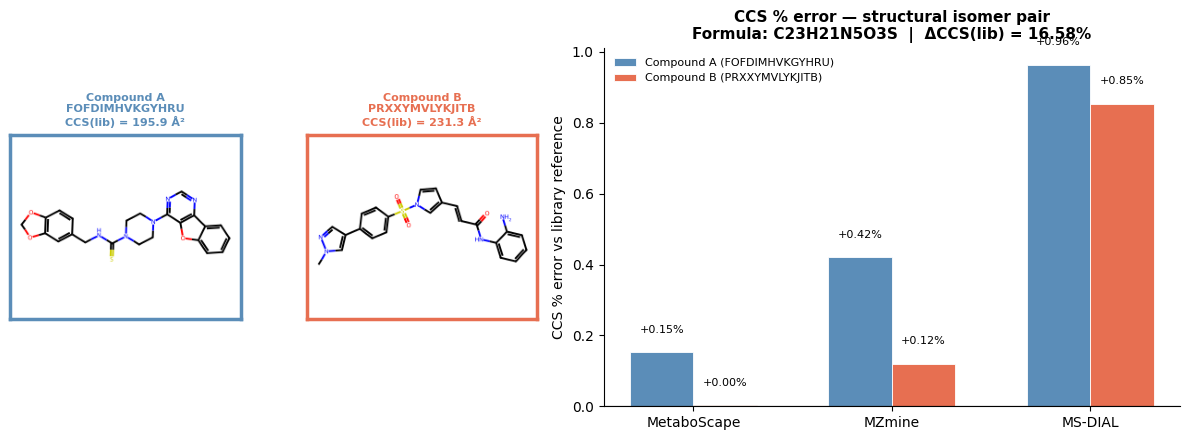

Saved → ../figures/isomer_ccs_error_example.png

Library CCS:  A=195.88  B=231.31
  MetaboScape   A=196.18  B=231.31
  MZmine        A=196.71  B=231.58
  MS-DIAL       A=197.77  B=233.28


In [10]:
from io import BytesIO

from rdkit import Chem
from rdkit.Chem import Draw

if not merged_feature_tables:
    print("Skipping example CCS error plot — no tool data loaded.")
else:
    # ── Helper: get best-score CCS per connectivity block for a tool ──────────
    def _tool_ccs_map(feature_df, score_thr=SCORE_THRESHOLD):
        df = feature_df.copy()
        df["inchikey_block1"] = df[INCHIKEY_COLUMN].apply(
            lambda x: x.split("-")[0] if pd.notna(x) else None
        )
        df_tp = df[
            (df[SCORE_COLUMN].notna())
            & (df[SCORE_COLUMN] >= score_thr)
            & (df["inchikey_block1"].isin(gt_blocks))
        ]
        return (
            df_tp.sort_values(SCORE_COLUMN, ascending=False)
            .groupby("inchikey_block1")["CCS"]
            .first()
            .to_dict()
        )

    tool_ccs_maps = {
        tool_key: _tool_ccs_map(merged_feature_tables[tool_key])
        for tool_key in ["metaboscape", "mzmine", "msdial"]
        if tool_key in merged_feature_tables
    }

    # ── Find a pair where all three tools detected both members ───────────────
    example_pair = None
    for _, row in all_pairs.sort_values("delta_ccs_pct", ascending=False).iterrows():
        block_a = row["inchikey_a"][:14]
        block_b = row["inchikey_b"][:14]
        if all(block_a in cmap and block_b in cmap for cmap in tool_ccs_maps.values()):
            example_pair = row
            break

    if example_pair is None:
        print("No isomer pair found that all three tools detected.")
    else:
        block_a = example_pair["inchikey_a"][:14]
        block_b = example_pair["inchikey_b"][:14]
        lib_ccs_a = example_pair["ccs_a"]
        lib_ccs_b = example_pair["ccs_b"]
        formula = example_pair["formula"]

        # Compute CCS % error for each tool and each compound
        tool_keys_ordered = [
            k for k in ["metaboscape", "mzmine", "msdial"] if k in tool_ccs_maps
        ]
        tool_labels = [TOOL_NAMES[k] for k in tool_keys_ordered]
        errors_a, errors_b = [], []
        for tk in tool_keys_ordered:
            ccs_tool_a = tool_ccs_maps[tk][block_a]
            ccs_tool_b = tool_ccs_maps[tk][block_b]
            errors_a.append((ccs_tool_a - lib_ccs_a) / lib_ccs_a * 100)
            errors_b.append((ccs_tool_b - lib_ccs_b) / lib_ccs_b * 100)

        # ── Render RDKit structure images for both compounds ──────────────────
        def _mol_to_image(inchikey, size=(250, 200)):
            smi = smiles_map.get(inchikey)
            if smi:
                mol = Chem.MolFromSmiles(smi)
                if mol:
                    return Draw.MolToImage(mol, size=size)
            return None

        img_a = _mol_to_image(example_pair["inchikey_a"])
        img_b = _mol_to_image(example_pair["inchikey_b"])

        # ── Plot ──────────────────────────────────────────────────────────────
        x = np.arange(len(tool_labels))
        bar_w = 0.32

        fig, axes_err = plt.subplots(
            1,
            3,
            figsize=(12, 4.5),
            gridspec_kw={"width_ratios": [1, 1, 2.5]},
        )

        # Panel A & B: RDKit structures
        for ax_struct, img_mol, block, lib_ccs, color, panel_label in [
            (axes_err[0], img_a, block_a, lib_ccs_a, "#5B8DB8", "Compound A"),
            (axes_err[1], img_b, block_b, lib_ccs_b, "#E76F51", "Compound B"),
        ]:
            if img_mol is not None:
                ax_struct.imshow(img_mol)
            ax_struct.set_xticks([])
            ax_struct.set_yticks([])
            for spine in ax_struct.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.5)
            ax_struct.set_title(
                f"{panel_label}\n{block}\nCCS(lib) = {lib_ccs:.1f} Å²",
                fontsize=8,
                color=color,
                fontweight="bold",
            )

        # Panel C: grouped bar chart of CCS % errors
        ax = axes_err[2]
        bars_a = ax.bar(
            x - bar_w / 2,
            errors_a,
            bar_w,
            label=f"Compound A ({block_a})",
            color="#5B8DB8",
            edgecolor="white",
            linewidth=0.6,
        )
        bars_b = ax.bar(
            x + bar_w / 2,
            errors_b,
            bar_w,
            label=f"Compound B ({block_b})",
            color="#E76F51",
            edgecolor="white",
            linewidth=0.6,
        )

        # Value labels on bars
        for bars in (bars_a, bars_b):
            for bar in bars:
                h = bar.get_height()
                va = "bottom" if h >= 0 else "top"
                offset = 0.05 if h >= 0 else -0.05
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + offset,
                    f"{h:+.2f}%",
                    ha="center",
                    va=va,
                    fontsize=8,
                )

        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(tool_labels, fontsize=10)
        ax.set_ylabel("CCS % error vs library reference", fontsize=10)
        ax.set_title(
            f"CCS % error — structural isomer pair\n"
            f"Formula: {formula}  |  ΔCCS(lib) = {example_pair['delta_ccs_pct']:.2f}%",
            fontsize=11,
            fontweight="bold",
        )
        ax.legend(fontsize=8, frameon=False)
        ax.spines[["top", "right"]].set_visible(False)

        plt.tight_layout()
        plt.savefig(
            "../figures/isomer_ccs_error_example.png",
            bbox_inches="tight",
            dpi=400,
        )
        plt.show()
        print(f"Saved → ../figures/isomer_ccs_error_example.png")
        print(f"\nLibrary CCS:  A={lib_ccs_a:.2f}  B={lib_ccs_b:.2f}")
        for tk in tool_keys_ordered:
            print(
                f"  {TOOL_NAMES[tk]:12s}  A={tool_ccs_maps[tk][block_a]:.2f}  "
                f"B={tool_ccs_maps[tk][block_b]:.2f}"
            )